In [1]:
import numpy as np
from tqdm import tqdm
from reinforce import reinforce, reinforce_with_baseline
import matplotlib.pyplot as plt
from short_corridor import ShortCorridorEnv

In [2]:
def experiment(
    env:ShortCorridorEnv,
    alpha:float,
    runs:int=100,
    episodes:int=1000,
    gamma:float=1.0
):
    rewards_per_episode = np.zeros(episodes)

    for _ in tqdm(range(runs), leave=False):
        theta = np.array([-1.47, 1.47])
        res = reinforce(
            env=env,
            episodes=episodes,
            theta=theta,
            alpha=alpha,
            gamma=gamma
        )
        rewards_per_episode += res['rewards_per_episode']
    rewards_per_episode /= runs
    return rewards_per_episode


In [3]:
def experiment_with_baseline(
    env:ShortCorridorEnv,
    alpha_theta:float,
    alpha_w:float,
    runs:int=100,
    episodes:int=1000,
    gamma:float=1.0
):
    rewards_per_episode = np.zeros(episodes)

    for _ in tqdm(range(runs), leave=False):
        theta = np.array([-1.47, 1.47])
        w = np.zeros(env.num_states)
        res = reinforce_with_baseline(
            env=env,
            episodes=episodes,
            theta=theta,
            w=w,
            alpha_theta=alpha_theta,
            alpha_w=alpha_w,
            gamma=gamma
        )
        rewards_per_episode += res['rewards_per_episode']
    rewards_per_episode /= runs
    return rewards_per_episode


In [4]:
env = ShortCorridorEnv(truncate=1000)

alpha = 2**-13
alpha_w = 0.001
runs = 100
episodes = 1000
gamma = 1.0

rpe_no_baseline = experiment(
    env=env,
    alpha=alpha,
    runs=runs,
    episodes=episodes,
    gamma=gamma
)

rpe_with_baseline = experiment_with_baseline(
    env=env,
    alpha_theta=alpha,
    alpha_w=alpha_w,
    runs=runs,
    episodes=episodes,
    gamma=gamma
)

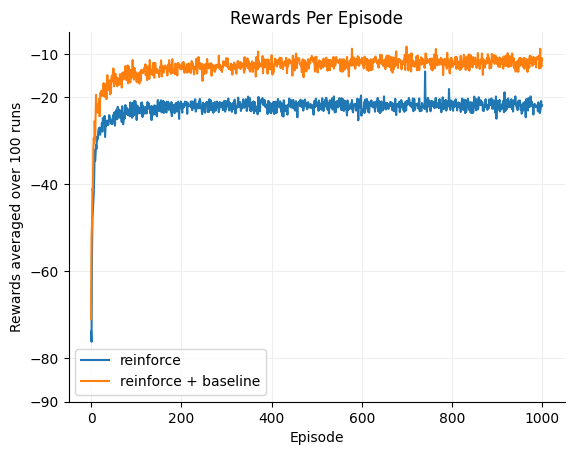

In [6]:
fig = plt.figure()
ax = plt.subplot(111)

ax.plot(rpe_no_baseline, label='reinforce')
ax.plot(rpe_with_baseline, label='reinforce + baseline')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(c="#eee")
ax.set_ylim([-90, -5])
ax.set_yticks([-10, -20, -40, -60, -80, -90])
ax.set_xlabel("Episode")
ax.set_ylabel("Rewards averaged over 100 runs")
ax.set_title("Rewards Per Episode");
ax.legend();